In [3]:
import pandas as pd

df = pd.read_csv("../dataset/pca_air_quality.csv")

df.head()

,0,1,2,3,4,5,6,Air Quality
0,-0.902660,-0.478854,-0.154381,-1.198434,-0.081664,-0.097742,-0.963201,2
1,0.248705,-1.440530,-0.090359,0.530530,-0.215979,-0.678043,-0.157543,2
2,0.669815,0.296412,-0.076713,0.756656,0.646763,-1.027232,-0.787394,2
3,-2.440927,-0.199095,-1.586505,0.444330,0.092047,0.537293,-0.525943,0
4,-2.112811,-0.000042,0.855052,-0.340631,0.002521,0.241215,0.485179,0


In [4]:
print(df.shape)

(5000, 8)


In [5]:
X = df.drop("Air Quality", axis=1)

y = df["Air Quality"]

print(X.shape)
print(y.shape)

(5000, 7)
(5000,)


In [6]:
import sklearn
print("Scikit-Learn Installed")

Scikit-Learn Installed


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (4000, 7)
Testing: (1000, 7)


In [9]:
# Logistic Regression(Model 1)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.927


In [10]:
#Decision Tree (Model 2)
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)


Decision Tree Accuracy: 0.883


In [11]:
#Random Forest(Model 3)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.92


In [ ]:
# Description:
# Random Forest combines multiple decision trees to improve prediction accuracy
# and reduce overfitting. The final prediction is based on the majority vote
# from all trees in the forest.

In [13]:
#SVM(Model 4)
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", acc_svm)

# Description:
# Support Vector Machine (SVM) finds the optimal boundary that separates
# different air quality categories. It is effective for classification tasks
# with complex patterns.

SVM Accuracy: 0.936


In [14]:
#KNN(Model 5)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", acc_knn)

# Description:
# K-Nearest Neighbors (KNN) classifies a data point based on the majority
# class of its nearest neighboring data points.

KNN Accuracy: 0.916


In [15]:
# Model Comparison Table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_svm,
        acc_knn
    ]
})

results_sorted = results.sort_values(
    by="Accuracy",
    ascending=False
)

results_sorted

,Model,Accuracy
3,SVM,0.936
0,Logistic Regression,0.927
2,Random Forest,0.920
4,KNN,0.916
1,Decision Tree,0.883


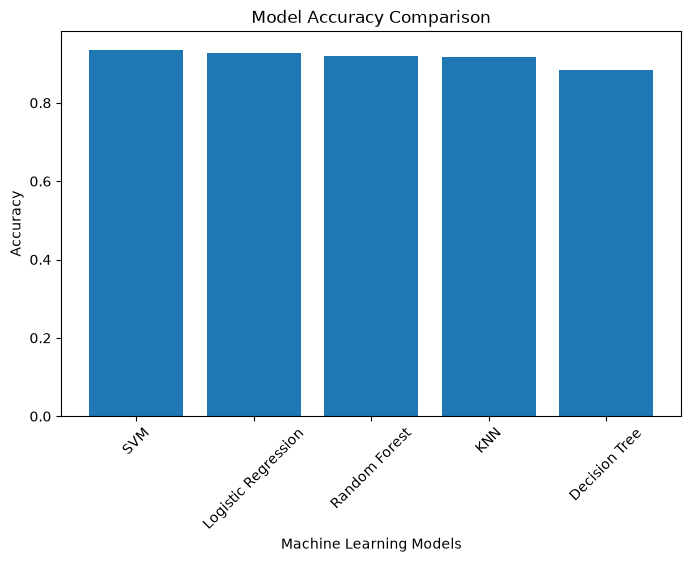

In [18]:
# Model Accuracy Comparison Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_sorted["Model"],
    results_sorted["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

In [19]:
# Hyperparameter Tuning for SVM

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.001],
    "kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("Best Cross Validation Accuracy:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross Validation Accuracy:
0.93825
